In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

file_path = os.path.join('..', 'data', 'processed', 'josaa_featured.csv')
df = pd.read_csv(file_path)

FIGURES_DIR = os.path.join('..', 'reports', 'figures')

COLORS = {
    'IIT'    : '#C62828',
    'NIT'    : '#1565C0',
    'IIIT'   : '#2E7D32',
    'GFTI'   : '#E65100',
    'OPEN'   : '#1565C0',
    'EWS'    : '#2E7D32',
    'OBC-NCL': '#F57F17',
    'SC'     : '#6A1B9A',
    'ST'     : '#B71C1C',
    'background': '#FAFAFA',
    'grid'      : '#EEEEEE',
    'text_dark' : '#212121',
    'text_light': '#757575',
}

plt.rcParams.update({
    'figure.facecolor' : COLORS['background'],
    'axes.facecolor'   : COLORS['background'],
    'axes.grid'        : True,
    'grid.color'       : COLORS['grid'],
    'grid.linewidth'   : 0.8,
    'font.family'      : 'DejaVu Sans',
})

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=180, bbox_inches='tight',
                facecolor=COLORS['background'])
    plt.show()
    print(f"Saved: {filename}")

print("Setup complete.")

Setup complete.


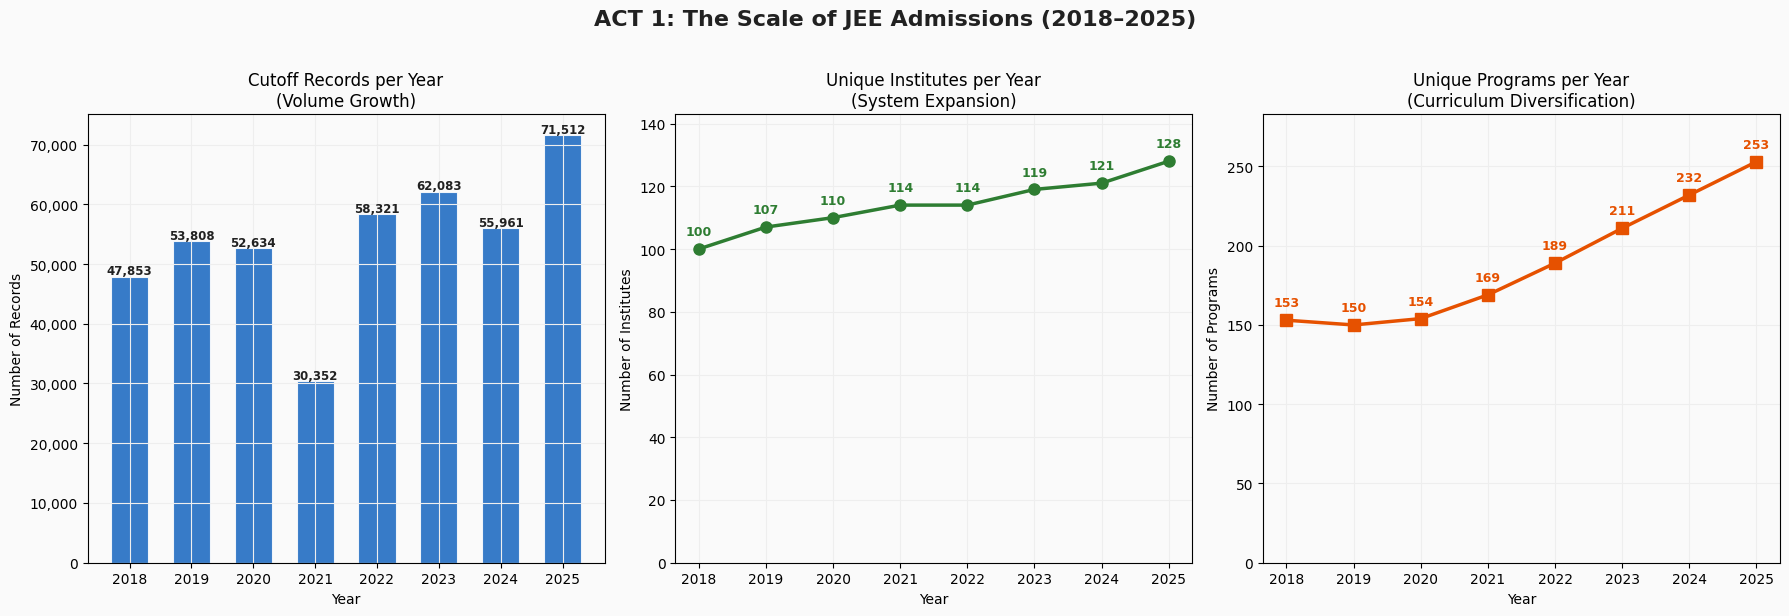

Saved: story_act1_landscape.png


In [2]:
# STORY: Show the sheer scale and growth of JEE admissions
# This sets context for everything that follows
# Audience instantly understands the stakes

yearly = df.groupby('year').agg(
    total_records=('closing_rank', 'count'),
    unique_institutes=('institute', 'nunique'),
    unique_programs=('program', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'ACT 1: The Scale of JEE Admissions (2018–2025)',
    fontsize=16, fontweight='bold', y=1.02,
    color=COLORS['text_dark']
)

# Chart 1: Records growth
axes[0].bar(
    yearly['year'], yearly['total_records'],
    color=COLORS['NIT'], edgecolor='white',
    linewidth=0.8, width=0.6, alpha=0.85
)
for x, y in zip(yearly['year'], yearly['total_records']):
    axes[0].text(x, y + 400, f'{y:,}',
                 ha='center', fontsize=8.5, fontweight='bold',
                 color=COLORS['text_dark'])
axes[0].set_title('Cutoff Records per Year\n(Volume Growth)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Records')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}')
)
axes[0].set_xticks(yearly['year'])

# Chart 2: Institutes over time
axes[1].plot(
    yearly['year'], yearly['unique_institutes'],
    marker='o', linewidth=2.5, markersize=8,
    color=COLORS['IIIT']
)
for x, y in zip(yearly['year'], yearly['unique_institutes']):
    axes[1].annotate(f'{y}', (x, y),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=9, fontweight='bold',
                     color=COLORS['IIIT'])
axes[1].set_title('Unique Institutes per Year\n(System Expansion)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Institutes')
axes[1].set_xticks(yearly['year'])
axes[1].set_ylim(0, yearly['unique_institutes'].max() + 15)

# Chart 3: Programs over time
axes[2].plot(
    yearly['year'], yearly['unique_programs'],
    marker='s', linewidth=2.5, markersize=8,
    color=COLORS['GFTI']
)
for x, y in zip(yearly['year'], yearly['unique_programs']):
    axes[2].annotate(f'{y}', (x, y),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center',
                     fontsize=9, fontweight='bold',
                     color=COLORS['GFTI'])
axes[2].set_title('Unique Programs per Year\n(Curriculum Diversification)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number of Programs')
axes[2].set_xticks(yearly['year'])
axes[2].set_ylim(0, yearly['unique_programs'].max() + 30)

plt.tight_layout()
save_fig('story_act1_landscape.png')

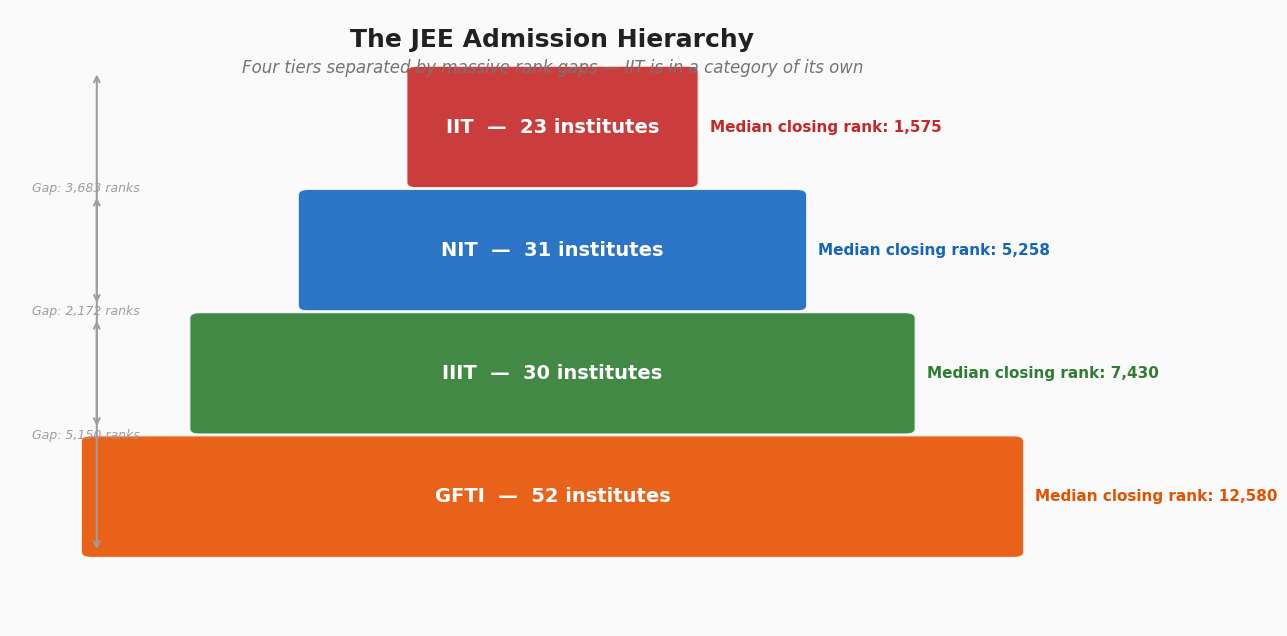

Saved: story_act2_hierarchy_pyramid.png


In [3]:
# STORY: Visualize the four-tier hierarchy as a pyramid
# with actual rank numbers anchoring each tier
# This is the single most important structural insight

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(COLORS['background'])
ax.set_facecolor(COLORS['background'])
ax.axis('off')

# Pyramid data
tiers = [
    {'label': 'IIT',  'colleges': 23,  'median': 1575,  'color': COLORS['IIT'],  'width': 0.25},
    {'label': 'NIT',  'colleges': 31,  'median': 5258,  'color': COLORS['NIT'],  'width': 0.45},
    {'label': 'IIIT', 'colleges': 30,  'median': 7430,  'color': COLORS['IIIT'], 'width': 0.65},
    {'label': 'GFTI', 'colleges': 52,  'median': 12580, 'color': COLORS['GFTI'], 'width': 0.85},
]

bar_height = 0.18
y_positions = [0.72, 0.52, 0.32, 0.12]

for tier, y in zip(tiers, y_positions):
    w = tier['width']
    x_start = (1 - w) / 2

    # Draw bar
    rect = mpatches.FancyBboxPatch(
        (x_start, y), w, bar_height,
        boxstyle='round,pad=0.01',
        facecolor=tier['color'],
        edgecolor='white',
        linewidth=2,
        alpha=0.9
    )
    ax.add_patch(rect)

    # Tier label
    ax.text(0.5, y + bar_height / 2,
            f"{tier['label']}  —  {tier['colleges']} institutes",
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            color='white')

    # Median rank annotation on right
    ax.text(x_start + w + 0.02,
            y + bar_height / 2,
            f"Median closing rank: {tier['median']:,}",
            ha='left', va='center',
            fontsize=11, color=tier['color'],
            fontweight='bold')

# Title and subtitle
ax.text(0.5, 0.97,
        'The JEE Admission Hierarchy',
        ha='center', va='top',
        fontsize=18, fontweight='bold',
        color=COLORS['text_dark'])

ax.text(0.5, 0.92,
        'Four tiers separated by massive rank gaps — IIT is in a category of its own',
        ha='center', va='top',
        fontsize=12, color=COLORS['text_light'],
        style='italic')

# Gap annotations
gaps = [
    (y_positions[0] + bar_height, y_positions[1],
     'Gap: 3,683 ranks'),
    (y_positions[1] + bar_height, y_positions[2],
     'Gap: 2,172 ranks'),
    (y_positions[2] + bar_height, y_positions[3],
     'Gap: 5,150 ranks'),
]

for y1, y2, label in gaps:
    mid_y = (y1 + y2) / 2
    ax.annotate('', xy=(0.08, y2), xytext=(0.08, y1),
                arrowprops=dict(arrowstyle='<->', color='#9E9E9E',
                               lw=1.5))
    ax.text(0.02, mid_y, label,
            ha='left', va='center',
            fontsize=9, color='#9E9E9E',
            style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

save_fig('story_act2_hierarchy_pyramid.png')

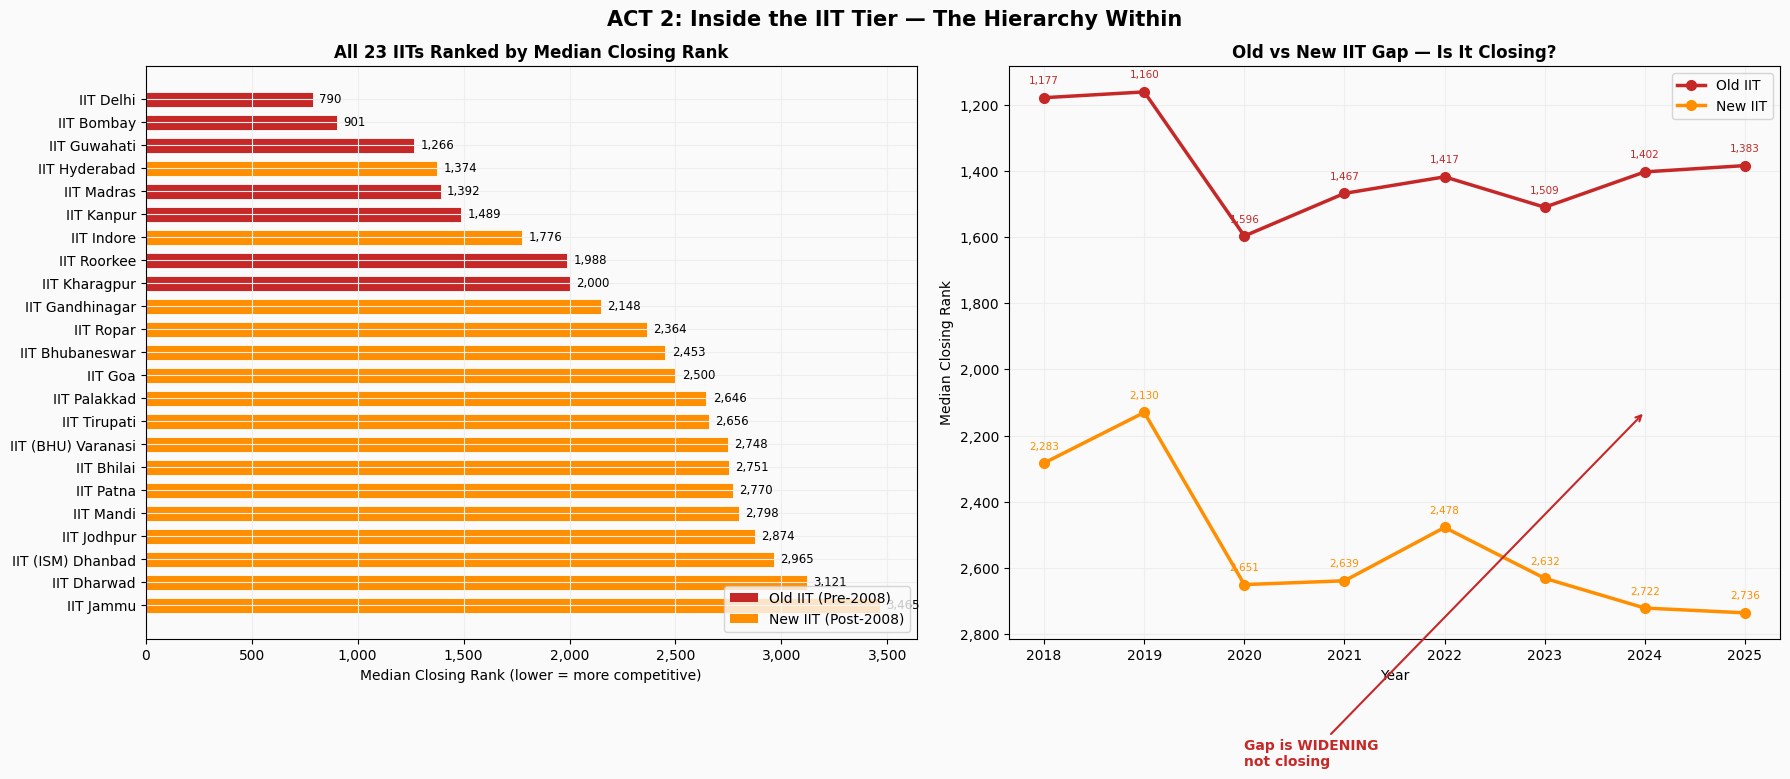

Saved: story_act2_iit_internal.png


In [4]:
# STORY: Even within IITs, there is a clear hierarchy
# And the Old vs New gap is NOT closing

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'ACT 2: Inside the IIT Tier — The Hierarchy Within',
    fontsize=15, fontweight='bold'
)

# Prepare IIT data
iit_df = df[df['institute_type'] == 'IIT'].copy()

old_iits = [
    'Indian Institute of Technology Bombay',
    'Indian Institute of Technology Delhi',
    'Indian Institute of Technology Kanpur',
    'Indian Institute of Technology Kharagpur',
    'Indian Institute of Technology Madras',
    'Indian Institute of Technology Roorkee',
    'Indian Institute of Technology Guwahati'
]

iit_df['generation'] = iit_df['institute'].apply(
    lambda x: 'Old IIT' if x in old_iits else 'New IIT'
)

def shorten_name(name):
    return (name
            .replace('Indian Institute of Technology ', 'IIT ')
            .replace('National Institute of Technology ', 'NIT ')
            .replace('Indian Institute of Information Technology ', 'IIIT '))

iit_ranking = (
    iit_df.groupby(['institute', 'generation'])['closing_rank']
    .median().reset_index()
    .sort_values('closing_rank')
)
iit_ranking['short_name'] = iit_ranking['institute'].apply(shorten_name)

gen_colors = {'Old IIT': '#C62828', 'New IIT': '#FF8F00'}
bar_colors = [gen_colors[g] for g in iit_ranking['generation']]

# Left: All IITs ranked
bars = axes[0].barh(
    iit_ranking['short_name'],
    iit_ranking['closing_rank'],
    color=bar_colors, edgecolor='white',
    linewidth=0.6, height=0.65
)

for bar, val in zip(bars, iit_ranking['closing_rank']):
    axes[0].text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f'{int(val):,}',
        va='center', fontsize=8.5
    )

axes[0].set_title('All 23 IITs Ranked by Median Closing Rank',
                  fontweight='bold')
axes[0].set_xlabel('Median Closing Rank (lower = more competitive)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}')
)

legend_elements = [
    mpatches.Patch(facecolor='#C62828', label='Old IIT (Pre-2008)'),
    mpatches.Patch(facecolor='#FF8F00', label='New IIT (Post-2008)')
]
axes[0].legend(handles=legend_elements, loc='lower right')

# Right: Gap trend
iit_df_trend = (
    iit_df.groupby(['year', 'generation'])['closing_rank']
    .median().reset_index()
)

for gen, color in gen_colors.items():
    data = iit_df_trend[
        iit_df_trend['generation'] == gen
    ].sort_values('year')
    axes[1].plot(
        data['year'], data['closing_rank'],
        marker='o', linewidth=2.5,
        markersize=7, label=gen, color=color
    )
    for _, row in data.iterrows():
        axes[1].annotate(
            f"{int(row['closing_rank']):,}",
            (row['year'], row['closing_rank']),
            textcoords='offset points',
            xytext=(0, 10), ha='center',
            fontsize=7.5, color=color
        )

axes[1].set_title('Old vs New IIT Gap — Is It Closing?',
                  fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Closing Rank')
axes[1].invert_yaxis()
axes[1].legend()
axes[1].set_xticks(sorted(df['year'].unique()))
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}')
)

# Add annotation
axes[1].annotate(
    'Gap is WIDENING\nnot closing',
    xy=(2024, 2128), xytext=(2020, 3200),
    fontsize=10, color='#C62828',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5)
)

plt.tight_layout()
save_fig('story_act2_iit_internal.png')

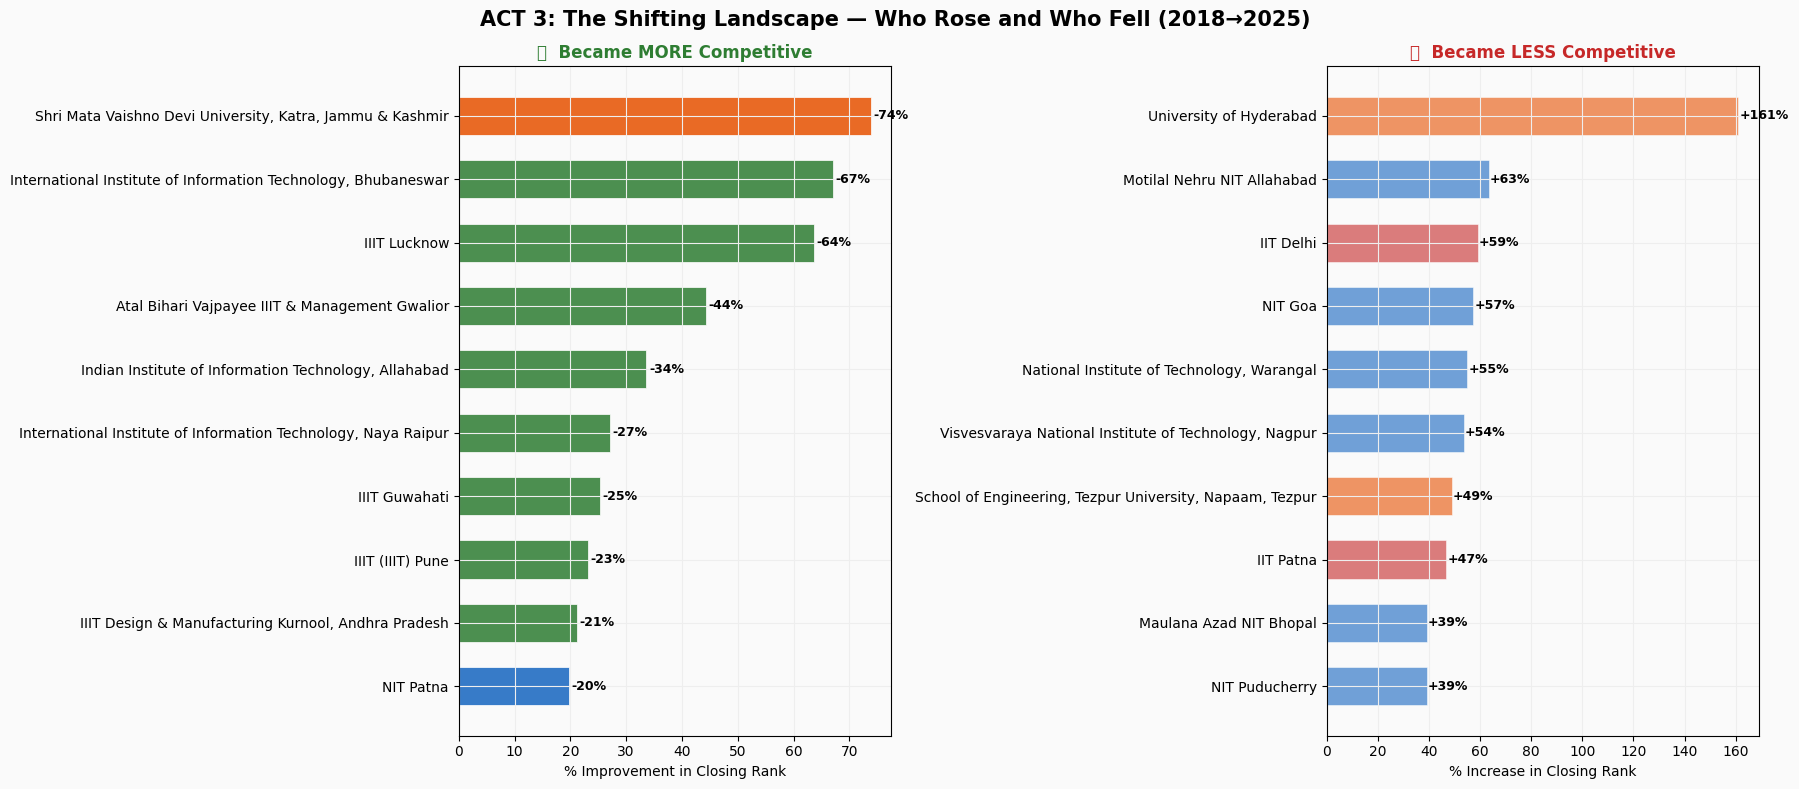

Saved: story_act3_movers.png


In [5]:
# STORY: The engineering landscape is shifting
# Some institutes are rising fast, others are falling
# This is the most actionable insight for students

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'ACT 3: The Shifting Landscape — Who Rose and Who Fell (2018→2025)',
    fontsize=15, fontweight='bold'
)

# Rebuild movement data
last_round_map = (
    df[df['is_special_round'] == False]
    .groupby(['year', 'institute_type'])['round']
    .max().reset_index()
    .rename(columns={'round': 'last_round'})
)

df_merged = df.merge(last_round_map, on=['year', 'institute_type'], how='left')

comp_eda = df_merged[
    (df_merged['round'] == df_merged['last_round']) &
    (df_merged['is_special_round'] == False) &
    (df_merged['quota'] == 'AI') &
    (df_merged['is_pwd'] == False) &
    (df_merged['gender_short'] == 'GN') &
    (df_merged['institute_type'].isin(['IIT', 'IIIT', 'GFTI']))
].copy()

last_round_nit = (
    df[
        (df['is_special_round'] == False) &
        (df['quota'].isin(['OS', 'AI'])) &
        (df['institute_type'] == 'NIT')
    ]
    .groupby('year')['round'].max()
    .reset_index().rename(columns={'round': 'last_round'})
)

df_nit = df.merge(last_round_nit, on='year', how='left')

comp_eda_nit = df_nit[
    (df_nit['round'] == df_nit['last_round']) &
    (df_nit['is_special_round'] == False) &
    (df_nit['quota'].isin(['OS', 'AI'])) &
    (df_nit['institute_type'] == 'NIT') &
    (df_nit['is_pwd'] == False) &
    (df_nit['gender_short'] == 'GN')
].copy()

comp_all = pd.concat([comp_eda, comp_eda_nit], ignore_index=True)

# Calculate movement
r2018 = (
    comp_all[comp_all['year'] == 2018]
    .groupby(['institute', 'institute_type'])['closing_rank']
    .median().reset_index()
    .rename(columns={'closing_rank': 'r2018'})
)
r2025 = (
    comp_all[comp_all['year'] == 2025]
    .groupby(['institute', 'institute_type'])['closing_rank']
    .median().reset_index()
    .rename(columns={'closing_rank': 'r2025'})
)

movement = r2018.merge(r2025, on=['institute', 'institute_type'])
movement['pct_change'] = (
    (movement['r2025'] - movement['r2018']) / movement['r2018'] * 100
).round(1)
movement['short_name'] = movement['institute'].apply(shorten_name)

# Remove architecture
movement = movement[
    ~movement['institute'].str.contains('Architecture|Planning', case=False)
]

# Top 10 improved
improved = movement.nsmallest(10, 'pct_change')
# Top 10 declined
declined = movement.nlargest(10, 'pct_change')

# Left: Most improved
imp_colors = [COLORS[t] for t in improved['institute_type']]
axes[0].barh(
    improved['short_name'],
    improved['pct_change'].abs(),
    color=imp_colors, edgecolor='white',
    linewidth=0.6, height=0.6, alpha=0.85
)
for bar, val in zip(axes[0].patches, improved['pct_change']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.0f}%',
        va='center', fontsize=9, fontweight='bold'
    )
axes[0].set_title('🔼  Became MORE Competitive',
                  color=COLORS['IIIT'], fontweight='bold', fontsize=12)
axes[0].set_xlabel('% Improvement in Closing Rank')
axes[0].invert_yaxis()

# Right: Most declined
dec_colors = [COLORS[t] for t in declined['institute_type']]
axes[1].barh(
    declined['short_name'],
    declined['pct_change'],
    color=dec_colors, edgecolor='white',
    linewidth=0.6, height=0.6, alpha=0.6
)
for bar, val in zip(axes[1].patches, declined['pct_change']):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'+{val:.0f}%',
        va='center', fontsize=9, fontweight='bold'
    )
axes[1].set_title('🔽  Became LESS Competitive',
                  color=COLORS['IIT'], fontweight='bold', fontsize=12)
axes[1].set_xlabel('% Increase in Closing Rank')
axes[1].invert_yaxis()

plt.tight_layout()
save_fig('story_act3_movers.png')

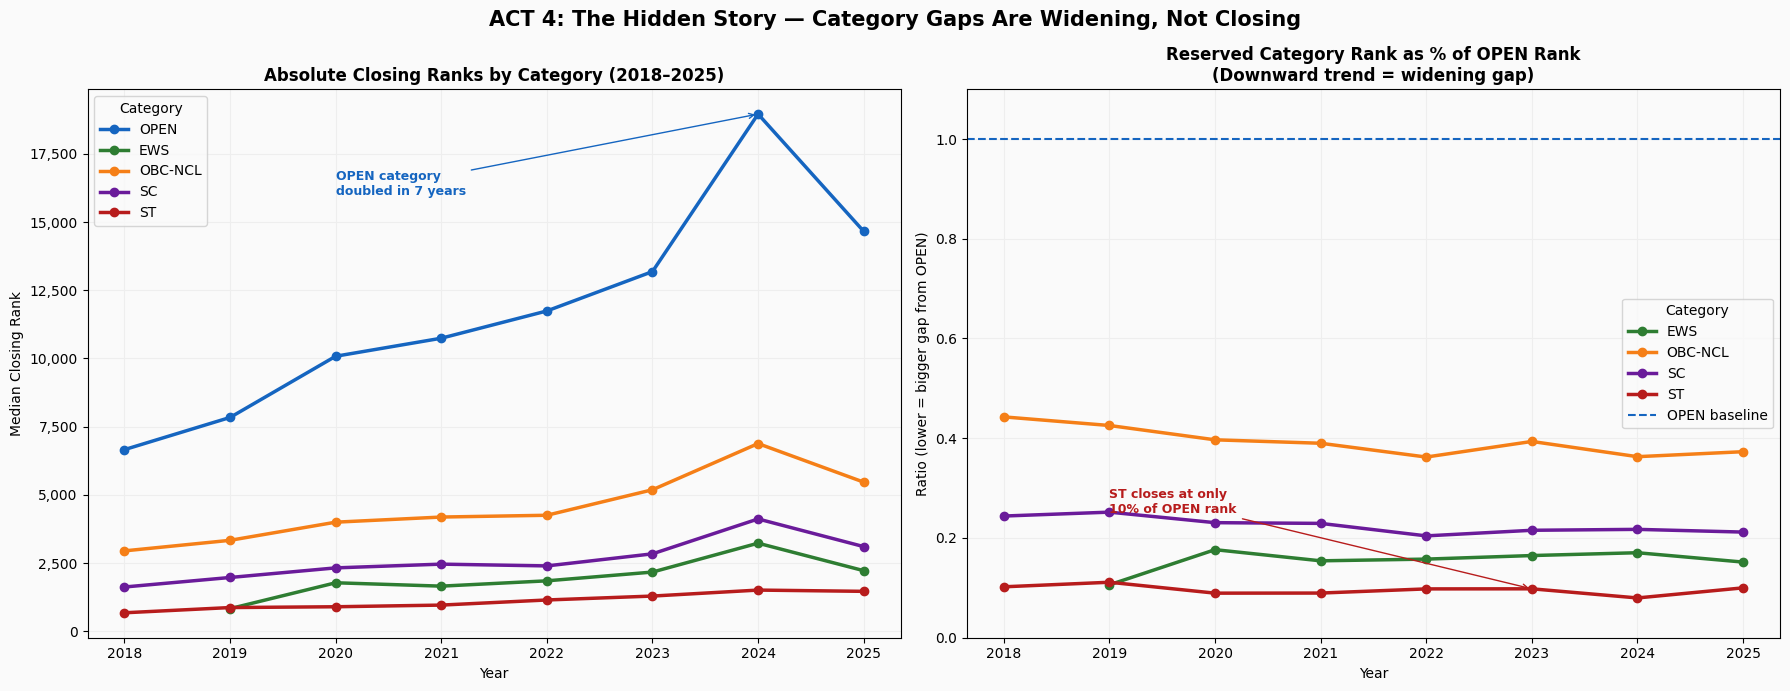

Saved: story_act4_equity_gap.png


In [6]:
# STORY: The most socially significant finding
# Reservation gaps are not closing — they are widening
# This is a policy-relevant insight

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'ACT 4: The Hidden Story — Category Gaps Are Widening, Not Closing',
    fontsize=15, fontweight='bold'
)

cat_order  = ['OPEN', 'EWS', 'OBC-NCL', 'SC', 'ST']
cat_colors = {
    'OPEN'   : COLORS['OPEN'],
    'EWS'    : COLORS['EWS'],
    'OBC-NCL': COLORS['OBC-NCL'],
    'SC'     : COLORS['SC'],
    'ST'     : COLORS['ST'],
}

df_cat = df_merged[
    (df_merged['round'] == df_merged['last_round']) &
    (df_merged['is_special_round'] == False) &
    (df_merged['quota'] == 'AI') &
    (df_merged['is_pwd'] == False) &
    (df_merged['gender_short'] == 'GN')
].copy()

cat_trend = (
    df_cat.groupby(['year', 'category_base'])['closing_rank']
    .median().reset_index()
)

# Left: Absolute trend
for cat in cat_order:
    data = cat_trend[
        cat_trend['category_base'] == cat
    ].sort_values('year')
    axes[0].plot(
        data['year'], data['closing_rank'],
        marker='o', linewidth=2.5, markersize=6,
        label=cat, color=cat_colors[cat]
    )

axes[0].set_title('Absolute Closing Ranks by Category (2018–2025)',
                  fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Closing Rank')
axes[0].set_xticks(sorted(df['year'].unique()))
axes[0].legend(title='Category')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}')
)

# Add annotation for OPEN spike
axes[0].annotate(
    'OPEN category\ndoubled in 7 years',
    xy=(2024, 18958), xytext=(2020, 16000),
    fontsize=9, color=COLORS['OPEN'],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLORS['OPEN'])
)

# Right: Gap ratio — the real story
pivot = cat_trend.pivot(
    index='year', columns='category_base', values='closing_rank'
)
gap_ratios = pivot.div(pivot['OPEN'], axis=0)

for cat in ['EWS', 'OBC-NCL', 'SC', 'ST']:
    if cat in gap_ratios.columns:
        axes[1].plot(
            gap_ratios.index,
            gap_ratios[cat],
            marker='o', linewidth=2.5, markersize=6,
            label=cat, color=cat_colors[cat]
        )

axes[1].axhline(
    y=1.0, color=COLORS['OPEN'],
    linestyle='--', linewidth=1.5, label='OPEN baseline'
)

# Annotate ST ratio
axes[1].annotate(
    'ST closes at only\n10% of OPEN rank',
    xy=(2023, 0.098), xytext=(2019, 0.25),
    fontsize=9, color=COLORS['ST'],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLORS['ST'])
)

axes[1].set_title('Reserved Category Rank as % of OPEN Rank\n'
                  '(Downward trend = widening gap)',
                  fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Ratio (lower = bigger gap from OPEN)')
axes[1].set_xticks(sorted(df['year'].unique()))
axes[1].legend(title='Category')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
save_fig('story_act4_equity_gap.png')

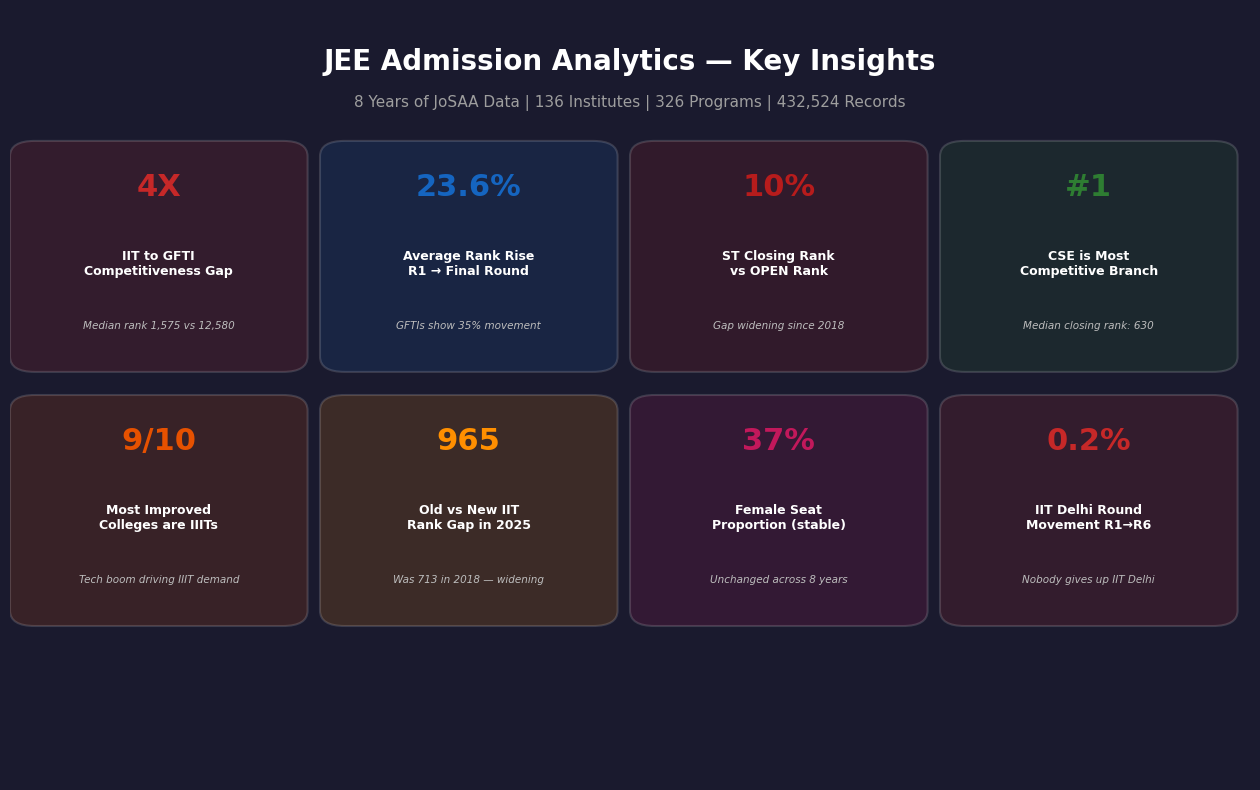

Saved: story_act5_insight_card.png


In [8]:
# STORY: Summarize all key findings as an insight card
# This is what you show at the end of a presentation
# Every number tells a story

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')
fig.patch.set_facecolor('#1A1A2E')

# Title
ax.text(0.5, 0.95,
        'JEE Admission Analytics — Key Insights',
        ha='center', va='top',
        fontsize=20, fontweight='bold', color='white')

ax.text(0.5, 0.89,
        '8 Years of JoSAA Data | 136 Institutes | 326 Programs | 432,524 Records',
        ha='center', va='top',
        fontsize=11, color='#9E9E9E')

# Define insight cards
insights = [
    {
        'number': '4X',
        'label': 'IIT to GFTI\nCompetitiveness Gap',
        'sub': 'Median rank 1,575 vs 12,580',
        'color': COLORS['IIT'],
        'x': 0.12, 'y': 0.68
    },
    {
        'number': '23.6%',
        'label': 'Average Rank Rise\nR1 → Final Round',
        'sub': 'GFTIs show 35% movement',
        'color': COLORS['NIT'],
        'x': 0.37, 'y': 0.68
    },
    {
        'number': '10%',
        'label': 'ST Closing Rank\nvs OPEN Rank',
        'sub': 'Gap widening since 2018',
        'color': COLORS['ST'],
        'x': 0.62, 'y': 0.68
    },
    {
        'number': '#1',
        'label': 'CSE is Most\nCompetitive Branch',
        'sub': 'Median closing rank: 630',
        'color': COLORS['IIIT'],
        'x': 0.87, 'y': 0.68
    },
    {
        'number': '9/10',
        'label': 'Most Improved\nColleges are IIITs',
        'sub': 'Tech boom driving IIIT demand',
        'color': COLORS['GFTI'],
        'x': 0.12, 'y': 0.35
    },
    {
        'number': '965',
        'label': 'Old vs New IIT\nRank Gap in 2025',
        'sub': 'Was 713 in 2018 — widening',
        'color': '#FF8F00',
        'x': 0.37, 'y': 0.35
    },
    {
        'number': '37%',
        'label': 'Female Seat\nProportion (stable)',
        'sub': 'Unchanged across 8 years',
        'color': '#C2185B',
        'x': 0.62, 'y': 0.35
    },
    {
        'number': '0.2%',
        'label': 'IIT Delhi Round\nMovement R1→R6',
        'sub': 'Nobody gives up IIT Delhi',
        'color': COLORS['IIT'],
        'x': 0.87, 'y': 0.35
    },
]

for ins in insights:
    # Card background
    card = mpatches.FancyBboxPatch(
        (ins['x'] - 0.1, ins['y'] - 0.13),
        0.2, 0.26,
        boxstyle='round,pad=0.02',
        facecolor=ins['color'],
        edgecolor='white',
        linewidth=1.5,
        alpha=0.15,
        transform=ax.transAxes
    )
    ax.add_patch(card)

    # Big number
    ax.text(ins['x'], ins['y'] + 0.09,
            ins['number'],
            ha='center', va='center',
            fontsize=22, fontweight='bold',
            color=ins['color'],
            transform=ax.transAxes)

    # Label
    ax.text(ins['x'], ins['y'] - 0.01,
            ins['label'],
            ha='center', va='center',
            fontsize=9, color='white',
            fontweight='bold',
            transform=ax.transAxes)

    # Sub text
    ax.text(ins['x'], ins['y'] - 0.09,
            ins['sub'],
            ha='center', va='center',
            fontsize=7.5, color='#BDBDBD',
            style='italic',
            transform=ax.transAxes)

save_fig('story_act5_insight_card.png')

In [9]:
# Generate a formal text findings document
# This becomes your project report section

findings = """
╔══════════════════════════════════════════════════════════════════╗
║         JEE COLLEGE ADMISSION ANALYTICS — FINDINGS REPORT       ║
║         8 Years of JoSAA Data (2018–2025)                        ║
╚══════════════════════════════════════════════════════════════════╝

DATASET OVERVIEW
─────────────────
- 432,524 cutoff records across 8 years
- 136 institutes: 23 IITs, 31 NITs, 30 IIITs, 52 GFTIs
- 326 unique programs across all institutes
- Data volume grew 49% from 2018 to 2025

FINDING 1: THE TIER GAP IS ENORMOUS
─────────────────────────────────────
- IIT median closing rank  : 1,575
- NIT median closing rank  : 5,258   (3.3x IIT)
- IIIT median closing rank : 7,430   (4.7x IIT)
- GFTI median closing rank : 12,580  (8.0x IIT)
- IIT-to-NIT gap (3,683) is larger than the NIT-to-IIIT gap (2,172)
- Top NITs (Surathkal: 1,772, Trichy: 1,852) beat 12 IITs in competitiveness

FINDING 2: IIT HIERARCHY IS STABLE BUT INTERNAL GAPS EXIST
────────────────────────────────────────────────────────────
- IIT Delhi (#1, rank 660) and IIT Bombay (#2, rank 797) are dominant
- IIT Guwahati ranks #3 — above IIT Madras and IIT Kanpur
- IIT Hyderabad (#4) — fastest-rising new IIT
- Old vs New IIT gap WIDENED from 713 (2018) to 965 (2025)
- New IITs are improving but old IITs are improving equally fast

FINDING 3: IIITs ARE THE FASTEST RISING TIER
──────────────────────────────────────────────
- 9 of top 10 most improved colleges (2018→2025) are IIITs
- IIIT Bhubaneswar improved 67%, IIIT Lucknow improved 63.6%
- IIIT median closing rank decreased 8,474 → 7,544 (becoming harder)
- Tech industry demand directly driving IIIT preference surge

FINDING 4: AI IS THE MOST COMPETITIVE BRANCH
──────────────────────────────────────────────
- AI (Artificial Intelligence) — median closing rank 630
- EE Dual Degree — 683 (IIT-only offering, very few seats)
- Math & Computing — 1,089 (22 institutes)
- CSE national median 3,401 — distorted by 109 institutes including low-tier
- New-age programs (AI, ML, DS, IoT) growing fastest in demand

FINDING 5: CATEGORY GAPS ARE WIDENING
───────────────────────────────────────
- ST category closes at only 10% of OPEN closing rank
- OBC-NCL ratio dropped from 0.443 (2018) to 0.373 (2025)
- EWS introduced in 2019, stabilized at 15-17% of OPEN rank
- Reservation policy creates access but gaps are not narrowing
- OPEN category closing rank doubled from 6,660 to 14,662 in 7 years

FINDING 6: GEOGRAPHY PREDICTS NIT COMPETITIVENESS
────────────────────────────────────────────────────
- South and West India NITs dominate top rankings
- NIT Surathkal (Karnataka) and NIT Trichy (Tamil Nadu) are #1 and #2
- Northeast NITs (Nagaland, Arunachal, Sikkim) are least competitive
- NIT Delhi ranks #4 despite being new — pure location premium effect
- Urban location is a significant predictor of NIT competitiveness

FINDING 7: ROUND MOVEMENT SIGNALS SEAT STABILITY
──────────────────────────────────────────────────
- Average closing rank rises 23.6% from Round 1 to final round
- IITs most stable: only 10.1% median movement
- GFTIs most volatile: 35% median movement
- IIT Delhi: only 0.2% movement — strongest prestige lock-in
- Students targeting GFTIs have real opportunity in later rounds

FINDING 8: GENDER SEAT PROPORTION IS STAGNANT
───────────────────────────────────────────────
- Female-Only seats stable at 36-38% across all 8 years
- FO seats close at higher rank (14,306) vs GN (12,066)
- FO-GN gap widening — female engineering demand growing slower
- Policy created seats but structural proportion has not shifted

DATA QUALITY NOTES
───────────────────
- 2021 data severely reduced due to COVID-19 disruption
- 2024 had only 5 rounds (vs 6 in other years)
- Architecture programs excluded — different entrance system
- NIT analysis uses OS+AI quota (AI quota insufficient for NITs)
- Round 7 existed in 2018-2019 as a special round (flagged)
"""

print(findings)

# Save to docs folder
report_path = os.path.join('..', 'docs', 'findings_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(findings)

print(f"\nFindings report saved to: {report_path}")


╔══════════════════════════════════════════════════════════════════╗
║         JEE COLLEGE ADMISSION ANALYTICS — FINDINGS REPORT       ║
║         8 Years of JoSAA Data (2018–2025)                        ║
╚══════════════════════════════════════════════════════════════════╝

DATASET OVERVIEW
─────────────────
- 432,524 cutoff records across 8 years
- 136 institutes: 23 IITs, 31 NITs, 30 IIITs, 52 GFTIs
- 326 unique programs across all institutes
- Data volume grew 49% from 2018 to 2025

FINDING 1: THE TIER GAP IS ENORMOUS
─────────────────────────────────────
- IIT median closing rank  : 1,575
- NIT median closing rank  : 5,258   (3.3x IIT)
- IIIT median closing rank : 7,430   (4.7x IIT)
- GFTI median closing rank : 12,580  (8.0x IIT)
- IIT-to-NIT gap (3,683) is larger than the NIT-to-IIIT gap (2,172)
- Top NITs (Surathkal: 1,772, Trichy: 1,852) beat 12 IITs in competitiveness

FINDING 2: IIT HIERARCHY IS STABLE BUT INTERNAL GAPS EXIST
─────────────────────────────────────────────────

In [ ]:
|